In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import skimage as ski
from ImageTiler import ImageTiler
from pnn_detection_pipeline import PNNPipeline
from Segmenter import Segmenter

filename = os.path.join(ski.data_dir, '/Users/emmanuelmakinde/Documents/00_Lab_Deemyad/00_Project_PNNs/Test_image/MAX_A1 P12 - 3 - C=2.tif')
img = ski.io.imread(filename)
y = ImageTiler(img, tile_size=256)
tile = y.tiles
x = PNNPipeline(hessian=False, difference_of_gaussian=True, roi_size=96, blob_thresh=0.05)
x.load_image(tile[513])
x.preprocess()
x.detect_candidates()
x.extract_rois()

Preprocessing...
Loading image...
Image loaded successfully.
Histogram equalization...
Histogram equalization done.
Applying gaussian...
Applying gaussian done.
Preprocessing complete.
Detecting candidates...
Detecting candidates done.
Adapting candidates...
__________________________
Adapting candidates done.
73 candidates found.
Extracting ROIs...


In [56]:
path_folder = '/Users/emmanuelmakinde/Documents/00_Lab_Deemyad/00_Project_PNNs/test_folder'
x.export_rois(path_folder, 'P12', 3, "WT")

In [57]:
segmenter = Segmenter(UNet=True)
segmenter.segment(x.candidates)

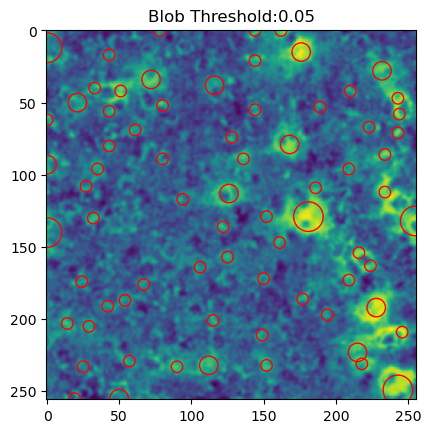

In [59]:
fig, ax = plt.subplots()
ax.imshow(x.enhanced_image)
for i, candidate in enumerate(x.candidates):
    ring = plt.Circle((candidate.x - x.tile.x, candidate.y - x.tile.y), candidate.radius, fill =  False, color='r')
    ax.add_patch(ring)
ax.set_title(f'Blob Threshold:{x.blob_thresh}')
plt.show()

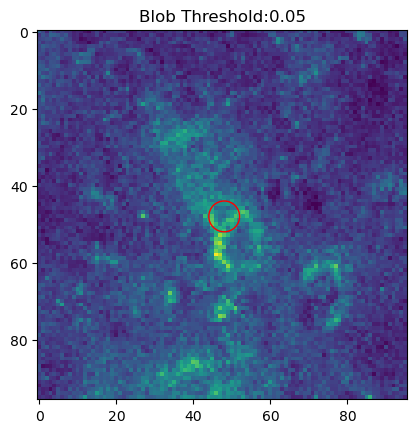

In [66]:
idx = 5   # Check out the different blobs


fig, ax = plt.subplots(1)
ax.imshow(x.candidates[idx].roi)
ring = plt.Circle((48,48), x.candidates[idx].radius, fill =  False, color='r')
ax.add_patch(ring)
ax.set_title(f'Blob Threshold:{x.blob_thresh}')
plt.show()